<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-11 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Generative Adversarial Networks </21> </html>

### Demonstration how to generate images of handwritten digits (like MNIST dataset) using
### a Deep Convolutional Generative Adversarial Network (DCGAN)

[source](https://arxiv.org/pdf/1511.06434.pdf)

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

##### (GANs) can be described as models which are trained simultaneously by an adversarial process.
A *generator* learns to create images that look real, while a *discriminator* learns to tell real images apart from fakes.
During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.

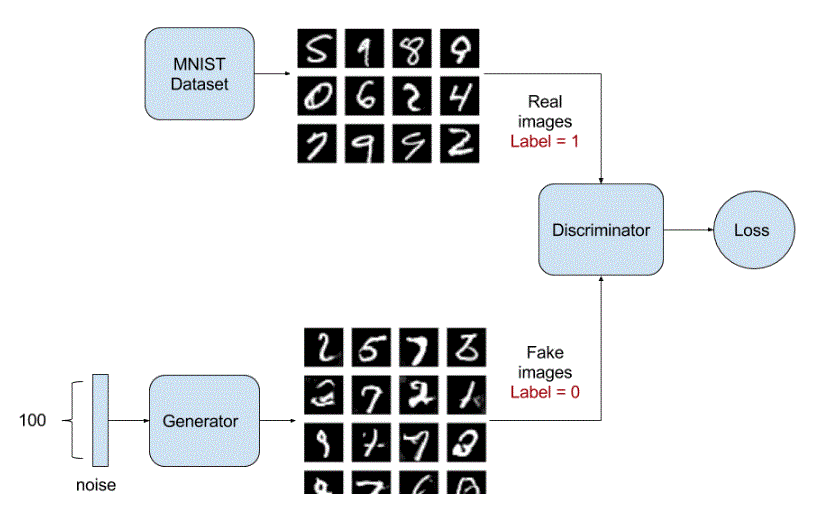

##### This notebook uses on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.

### Import

image.png

In [1]:
import os
import time
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython import display
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)


2026-05-01 06:03:24.059149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777615404.544694      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777615404.654029      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777615405.652747      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777615405.652782      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777615405.652786      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
# Check GPU availability (optional but helpful for faster training)
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


image.png

In [3]:
# Load the MNIST dataset
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)


In [4]:
# We do not need labels for GAN training because this is an unsupervised task.


______________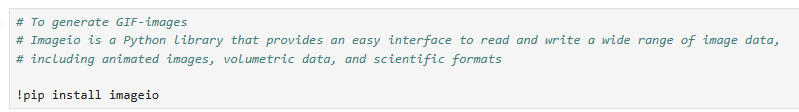

In [5]:
# Reshape and normalize images to the range [-1, 1]
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

print("Min pixel value:", train_images.min())
print("Max pixel value:", train_images.max())
print("New image shape:", train_images.shape)


Min pixel value: -1.0
Max pixel value: 1.0
New image shape: (60000, 28, 28, 1)


In [6]:
# The generator uses tanh in the final layer, so scaling images to [-1, 1] helps the model learn properly.


______________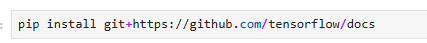

In [7]:
# Define training constants
BUFFER_SIZE = 60000
BATCH_SIZE = 256


In [8]:
print("BUFFER_SIZE =", BUFFER_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)


BUFFER_SIZE = 60000
BATCH_SIZE = 256


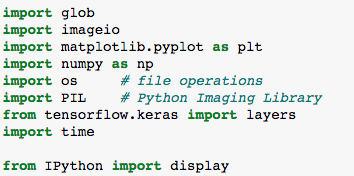


In [9]:
# Create a tf.data dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


I0000 00:00:1777615444.725057      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777615444.731133      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
# This creates an efficient input pipeline that shuffles the images and feeds them to the model in mini-batches.


### MNIST Dataset
After treining the generator will generate handwritten digits resembling the MNIST data.


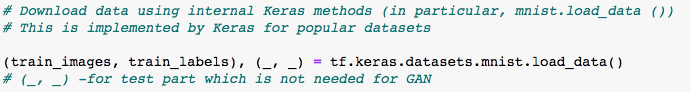

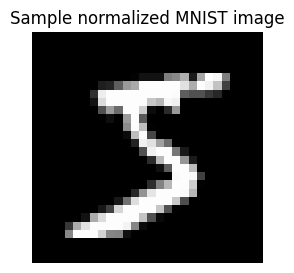

In [11]:
# Display one sample image from the dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
plt.imshow(train_images[0, :, :, 0], cmap='gray')
plt.title("Sample normalized MNIST image")
plt.axis('off')
plt.show()


In [12]:
# The image may look slightly different because it is normalized, but it still represents a handwritten digit.


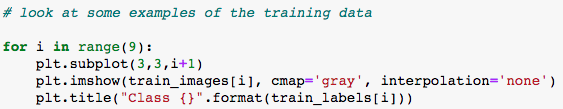

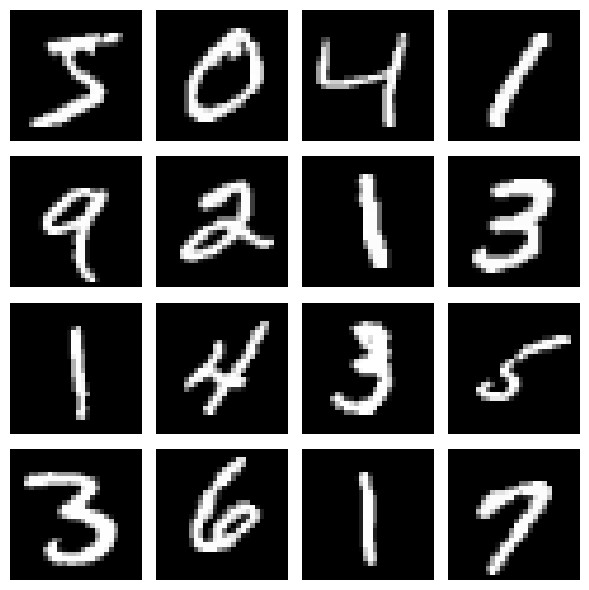

In [13]:
# Display 16 sample images from MNIST
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


In [14]:
# These are the real images the discriminator will learn from during training.


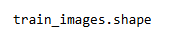

In [15]:
# Show one batch shape
for image_batch in train_dataset.take(1):
    print("Batch shape:", image_batch.shape)


Batch shape: (256, 28, 28, 1)


In [16]:
# Each batch is a group of images that will be used in one training step.


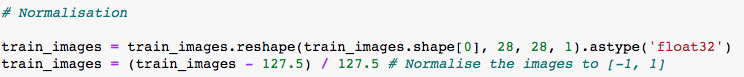

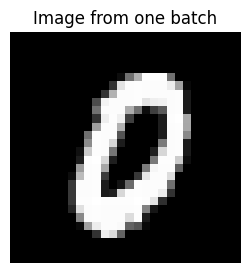

In [17]:
# Show the first image from one training batch
for image_batch in train_dataset.take(1):
    plt.figure(figsize=(3, 3))
    plt.imshow(image_batch[0, :, :, 0], cmap='gray')
    plt.title("Image from one batch")
    plt.axis('off')
    plt.show()


In [18]:
# The dataset is now ready to be used by the GAN.


_______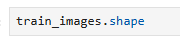

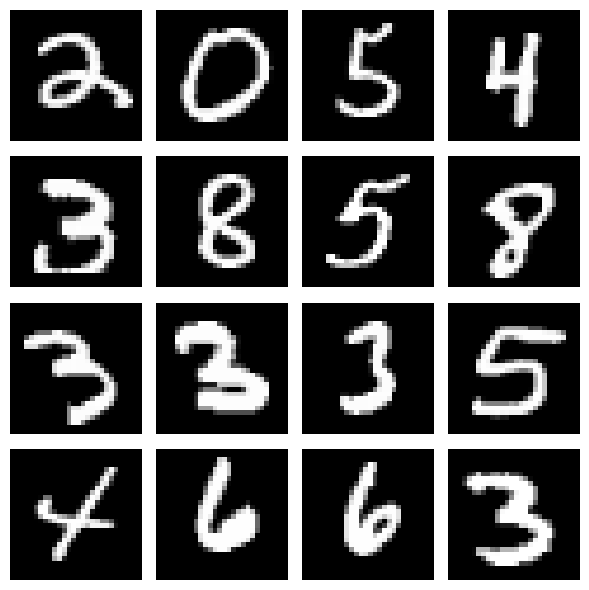

In [19]:
# Show multiple images from a training batch
for image_batch in train_dataset.take(1):
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(image_batch[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


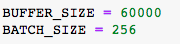

In [20]:
# Optional: inspect the dataset object
train_dataset


<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

In [21]:
#

In [22]:
#tf.data.Dataset.from_tensor_slices?

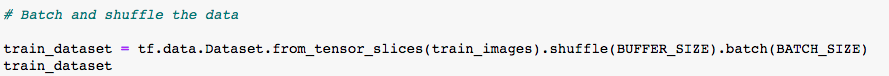

In [23]:
# Build the generator model
from tensorflow.keras import layers

def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model


generator = make_generator_model()
generator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [24]:
# The generator converts random noise of size 100 into a 28x28x1 image.


### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

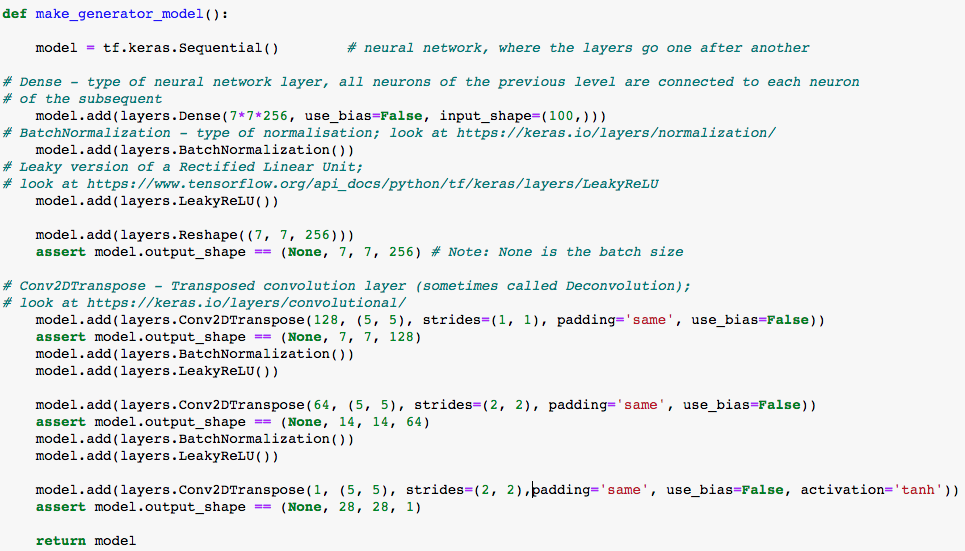


In [25]:
# Test the generator with random noise
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)


I0000 00:00:1777615448.858618      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Generated image shape: (1, 28, 28, 1)


In [26]:
# The output shape matches the MNIST image size, so the generator architecture is correct.


Use the generator to create an image.


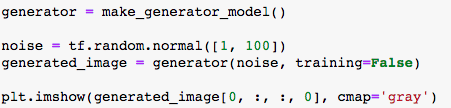



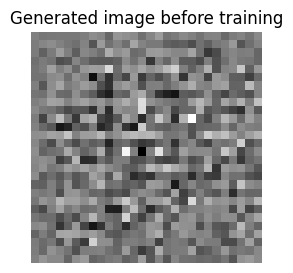

In [27]:
# Display one generated image before training
plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("Generated image before training")
plt.axis('off')
plt.show()


In [28]:
# Before training, the generator has learned nothing, so the image looks like random noise.


image.png



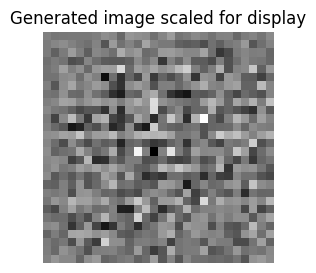

In [29]:
# Display one generated image with pixel values scaled for visualization
plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0] * 127.5 + 127.5, cmap='gray')
plt.title("Generated image scaled for display")
plt.axis('off')
plt.show()


In [30]:
# Why does the image not have structure?
print(
    "The image has no clear structure because the generator is still untrained. "
    "Its weights are random, so it only transforms random noise into another random pattern."
)


The image has no clear structure because the generator is still untrained. Its weights are random, so it only transforms random noise into another random pattern.


In [31]:
# After many training epochs, the generator gradually learns patterns such as strokes, loops, and digit shapes.


### The Discriminator

The discriminator is a CNN-based image classifier.

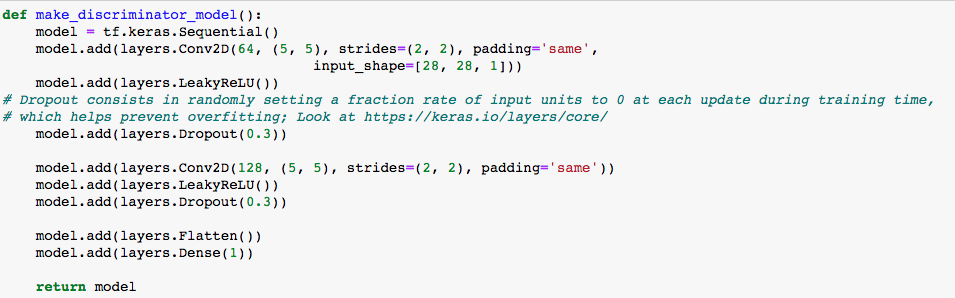

In [32]:
# Build the discriminator model

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


discriminator = make_discriminator_model()
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# The discriminator receives an image and returns one score indicating whether it looks real or fake.


Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

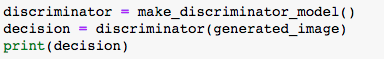

In [34]:
# Test the discriminator on one generated image
prediction = discriminator(generated_image)
print("Discriminator output for one fake image:", prediction.numpy())


Discriminator output for one fake image: [[0.00147157]]


image.png

In [35]:
# Test the discriminator on a batch of generated images
noise = tf.random.normal([16, 100])
fake_images = generator(noise, training=False)
fake_predictions = discriminator(fake_images, training=False)

print("Discriminator output shape:", fake_predictions.shape)
print(fake_predictions[:5])


Discriminator output shape: (16, 1)
tf.Tensor(
[[-0.0041254 ]
 [-0.00144438]
 [-0.0029555 ]
 [-0.0022958 ]
 [-0.00375733]], shape=(5, 1), dtype=float32)


## Define the loss and optimizers

Define loss functions and optimizers for both models.


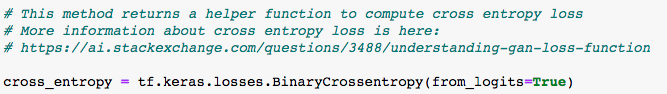

In [36]:
# Binary cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


In [37]:
print(cross_entropy)


<LossFunctionWrapper(<function binary_crossentropy at 0x7e4230fb5b20>, kwargs={'from_logits': True, 'label_smoothing': 0.0, 'axis': -1})>


### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

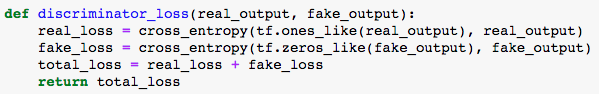

In [38]:
# Discriminator loss

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss


In [39]:
# The discriminator is rewarded when it predicts real images as 1 and fake images as 0.


### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, we will compare the discriminators decisions on the generated images to an array of 1s.

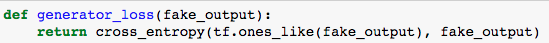

In [40]:
# Generator loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


In [41]:
# The generator tries to fool the discriminator, so it wants fake images to be classified as real (1).


The discriminator and the generator optimizers are different since we will train two networks separately.

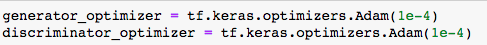

In [42]:
# Define optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


In [43]:
print(generator_optimizer)
print(discriminator_optimizer)


image.png

In [44]:
# Quick loss test using current fake images and one batch of real images
for real_batch in train_dataset.take(1):
    random_noise = tf.random.normal([real_batch.shape[0], 100])
    generated_batch = generator(random_noise, training=False)
    real_output = discriminator(real_batch, training=False)
    fake_output = discriminator(generated_batch, training=False)
    print("Initial discriminator loss:", float(discriminator_loss(real_output, fake_output)))
    print("Initial generator loss:", float(generator_loss(fake_output)))


Initial discriminator loss: 1.3857167959213257
Initial generator loss: 0.6938074231147766


### Save checkpoints
It is useful in case a long running training task is interrupted.


image.png

In [45]:
# Set up checkpoints
import os
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)


In [46]:
print("Checkpoint directory:", checkpoint_dir)


Checkpoint directory: ./training_checkpoints


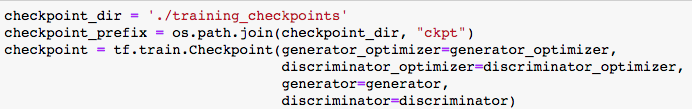

In [47]:
# Number of examples to generate for monitoring progress
num_examples_to_generate = 16
noise_dim = 100
seed = tf.random.normal([num_examples_to_generate, noise_dim])

print("Noise dimension:", noise_dim)
print("Seed shape:", seed.shape)


Noise dimension: 100
Seed shape: (16, 100)


In [48]:
# The same seed is reused each epoch so that progress can be compared fairly over time.


## Training loop



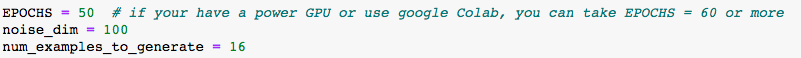


In [49]:
# One training step for both generator and discriminator
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


In [50]:
# In each step, the discriminator learns to detect fakes and the generator learns to create better images.


image.png

In [51]:
# Generate and save images after each epoch

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}', y=0.95)
    plt.tight_layout()
    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()


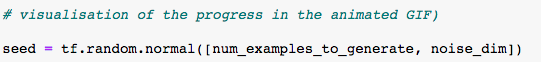

In [52]:
# Full training loop
EPOCHS = 17

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_loss_value = None
        disc_loss_value = None

        for image_batch in dataset:
            gen_loss_value, disc_loss_value = train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        epoch_time = time.time() - start
        print(
            f'Epoch {epoch + 1}/{epochs} | '
            f'Generator loss: {float(gen_loss_value):.4f} | '
            f'Discriminator loss: {float(disc_loss_value):.4f} | '
            f'Time: {epoch_time:.2f} sec'
        )

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)


In [53]:
print("Planned number of epochs:", EPOCHS)


Planned number of epochs: 17


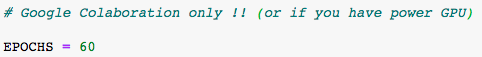

In [54]:
# This loop trains both networks together. As training improves, the saved images should look more like real digits.


In [55]:
#

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

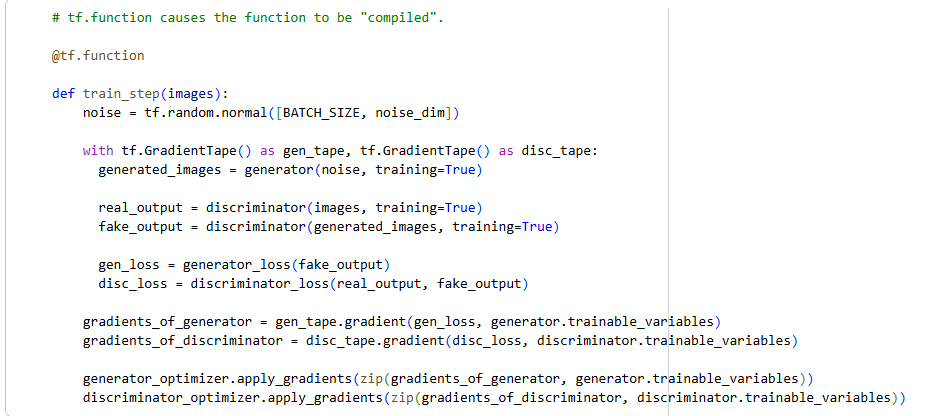

In [56]:
# Run a quick single training step on one batch to confirm the pipeline works
for sample_batch in train_dataset.take(1):
    g_loss, d_loss = train_step(sample_batch)
    print("Generator loss after one test step:", float(g_loss))
    print("Discriminator loss after one test step:", float(d_loss))


E0000 00:00:1777615455.014502      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Generator loss after one test step: 0.701262891292572
Discriminator loss after one test step: 1.3821662664413452


In [57]:
# This is only a quick functional test. The actual learning happens when the full training loop runs.


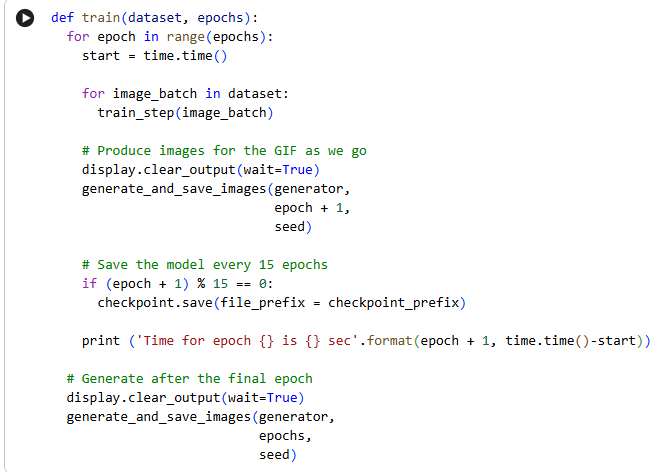

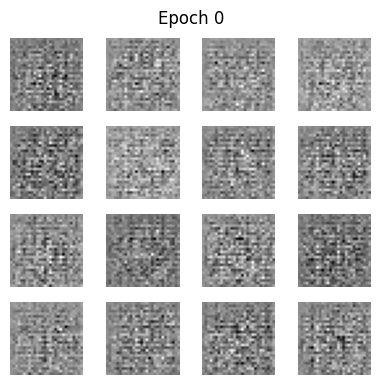

In [58]:
# Show generated images using the fixed seed before full training
generate_and_save_images(generator, 0, seed)


In [59]:
#

**Generate and save images**



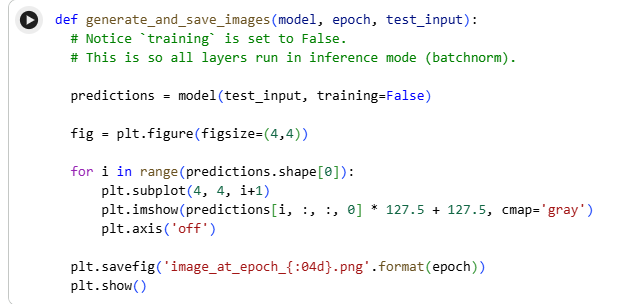

In [60]:
# Create the output folder if it does not exist
os.makedirs(checkpoint_dir, exist_ok=True)
print("Ready to save generated images and checkpoints.")


Ready to save generated images and checkpoints.


In [61]:
# Images saved after each epoch will later be combined into a GIF animation.


## Train the model
train() - training the generator and discriminator simultaneously.
It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits.

In [62]:
# Save your Jupyter Notebook before start the next cell

### Before starting the next cell, read the Lab Logbook requirements.
### To take a screenshot of the required epoch, use Shift+Window+S for Windows
### and Shift+Command+5 for Mac.

image.png

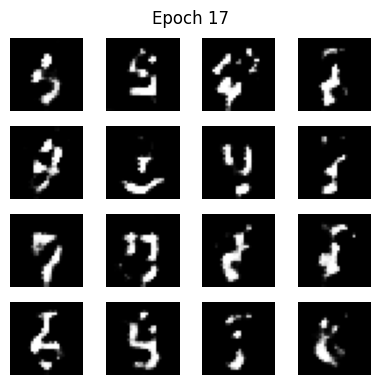

In [63]:
# Start training
from IPython import display
import time
train(train_dataset, EPOCHS)


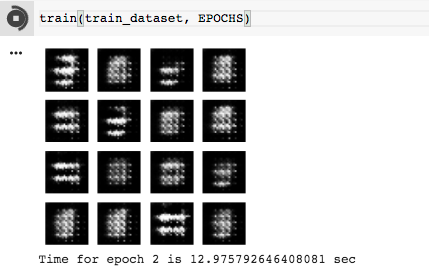

image.png

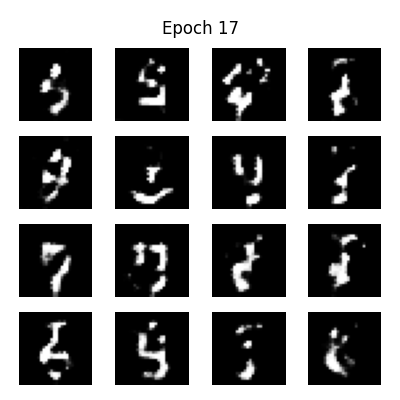

In [64]:
# Display one of the final generated image grids (if it exists)
from PIL import Image
latest_image = f'image_at_epoch_{EPOCHS:04d}.png'
if os.path.exists(latest_image):
    display.display(Image.open(latest_image))
else:
    print("No saved image found yet. Run the training cell first.")


Restore the latest checkpoint.

image.png

In [65]:
# Restore the latest checkpoint
latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir)
if latest_ckpt:
    checkpoint.restore(latest_ckpt)
    print("Restored checkpoint:", latest_ckpt)
else:
    print("No checkpoint found.")


Restored checkpoint: ./training_checkpoints/ckpt-1


In [66]:
# Restoring is useful if training stops and you want to continue later from the saved state.


### Show the result as a GIF-file


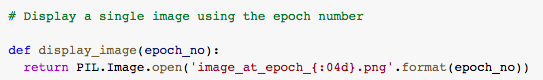

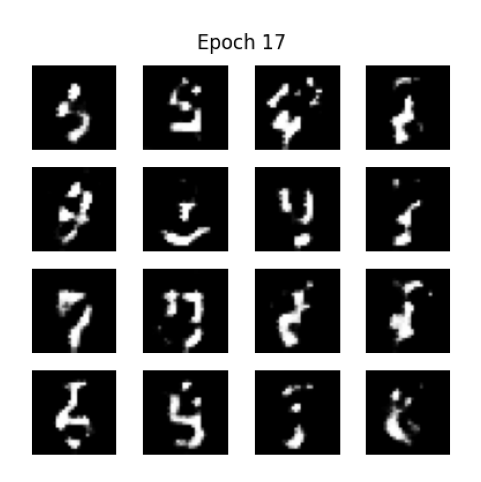

In [67]:
# Preview the final epoch image if available
final_image_path = f'image_at_epoch_{EPOCHS:04d}.png'
if os.path.exists(final_image_path):
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(final_image_path))
    plt.axis('off')
    plt.show()
else:
    print("Final image not available yet.")


In [68]:
# This image should show digits becoming more recognizable after training.


image.png

In [69]:
# Display the GIF if it already exists
gif_path = 'dcgan.gif'
if os.path.exists(gif_path):
    display.display(display.Image(filename=gif_path))
else:
    print("GIF not created yet. Run the GIF creation cell first.")


GIF not created yet. Run the GIF creation cell first.


In [70]:
# Describe the results
print(
    "At the start, the generated images look like random noise. "
    "After training, the generator learns digit-like patterns, so the images become clearer and start resembling MNIST handwritten numbers."
)


At the start, the generated images look like random noise. After training, the generator learns digit-like patterns, so the images become clearer and start resembling MNIST handwritten numbers.


In [71]:
# Good GAN training usually shows a gradual improvement in sharpness and digit structure across epochs.


Use `imageio` to create an animated gif using the images saved during training.

_________________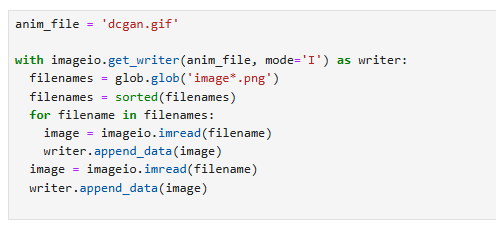

In [72]:
# Create an animated GIF from saved epoch images
import imageio
import glob
anim_file = 'dcgan.gif'
with imageio.get_writer(anim_file, mode='I', duration=0.5) as writer:
    filenames = sorted(glob.glob('image_at_epoch_*.png'))
    if not filenames:
        raise FileNotFoundError("No saved epoch images found. Train the model first.")

    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"GIF saved as: {anim_file}")


/tmp/ipykernel_57/977896325.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved as: dcgan.gif


In [73]:
# The GIF shows how the generated digits improve from epoch to epoch.


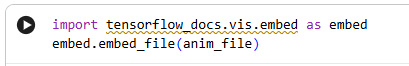

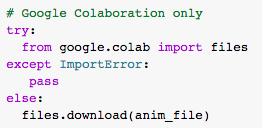

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### You must copy a screenshot of the GAN training result at a specific epoch to your logbook. The screenshot must contain the digital images, the epoch number and the time spent training for this epoch.

### Determine this epoch number using the following method:

#### Take the last two digits from your SID.
#### If this number is less than or equal to 50, it is the required epoch number.
#### If it exceeds 50, divide it by 50 and round up if necessary.
#### For example, if your SID is 2187467, and the last two digits are 67, which is greater than 50.
#### Divide by 2, resulting in 33.5. Round up to 34, and this becomes your epoch number.

<html> <h4 style="font-style:bold; color:red;"> NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB. </h4> </html>

In [76]:
# Calculate the required logbook epoch number from your SID

def required_epoch_from_sid(sid):
    last_two_digits = int(str(sid)[-2:])
    if last_two_digits <= 50:
        return last_two_digits
    return math.ceil(last_two_digits / 2)

# Example usage:
student_sid = "2524417"  # replace this with your own SID
required_epoch = required_epoch_from_sid(student_sid)

print("SID:", student_sid)
print("Required epoch number for the logbook:", required_epoch)


SID: 2524417
Required epoch number for the logbook: 17
